# Environment Setup & Dependencies

In [28]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Downloading and Loading Model

In [13]:
os.makedirs('models', exist_ok=True)
proto_path = os.path.join('models', 'deploy.prototxt')
model_path = os.path.join('models', 'res10_300x300_ssd_iter_140000.caffemodel')

proto_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(proto_path):
    urllib.request.urlretrieve(proto_url, proto_path)
if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

print("Model files downloaded successfully!")

Model files downloaded successfully!


In [12]:
net = cv2.dnn.readNetFromCaffe(proto_path, model_path)

net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)

print("OpenCV DNN loaded successfully on CUDA/GPU!")

OpenCV DNN loaded successfully on CUDA/GPU!


# Defining the Detection Function

In [10]:
def detect_faces_dnn(image_path, confidence_threshold=0.5):
    """Detects faces using the OpenCV DNN model and draws bounding boxes."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error loading image: {image_path}")
        return None, []

    (h, w) = img_bgr.shape[:2]
    # Create a 300x300 blob for the SSD network
    blob = cv2.dnn.blobFromImage(
        cv2.resize(img_bgr, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0)
    )

    net.setInput(blob)
    detections = net.forward()

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    faces = []

    # Loop through detection candidates
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            # Ensure bounding box stays within image boundaries
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w - 1, endX), min(h - 1, endY)

            faces.append((startX, startY, endX - startX, endY - startY))
            cv2.rectangle(img_rgb, (startX, startY), (endX, endY), (0, 255, 0), 2)

    return img_rgb, faces

# Data Processing and Visualization

In [25]:
data_dir = 'data'
image_files = sorted([f for f in os.listdir(data_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

results = {}

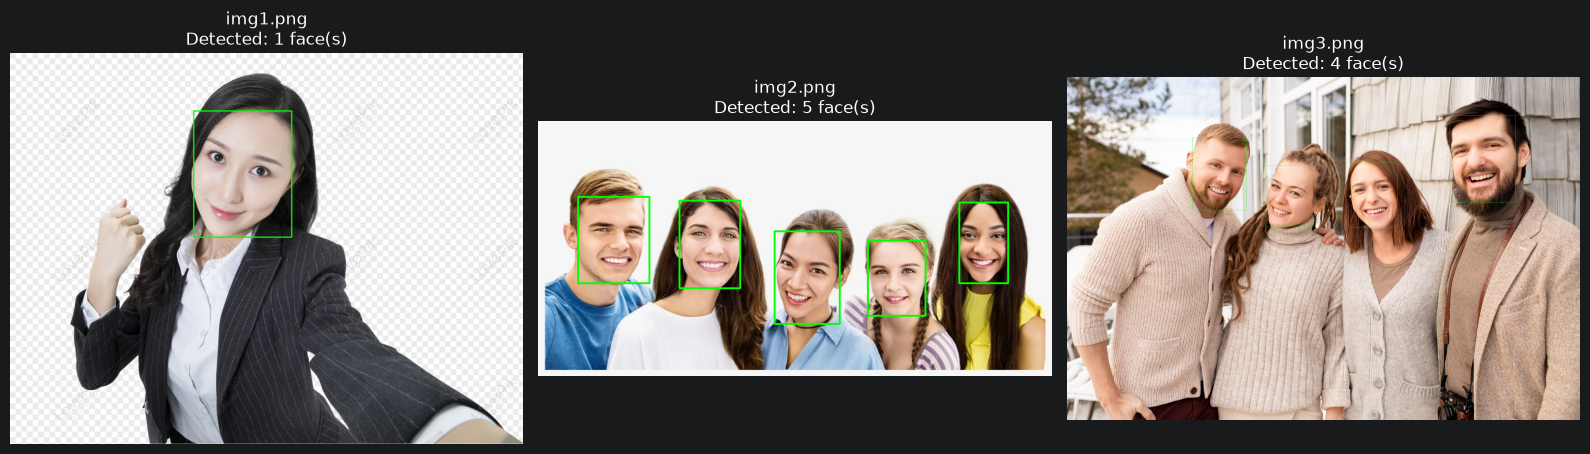

In [26]:
# Set up grid plot
fig, axes = plt.subplots(1, len(image_files), figsize=(16, 5))

if len(image_files) == 1:
    axes = [axes]

for ax, img_name in zip(axes, image_files):
    img_path = os.path.join(data_dir, img_name)
    processed_img, faces = detect_faces_dnn(img_path, confidence_threshold=0.5)

    if processed_img is not None:
        results[img_name] = len(faces)
        ax.imshow(processed_img)
        ax.set_title(f"{img_name}\nDetected: {len(faces)} face(s)")
        ax.axis('off')

plt.tight_layout()
plt.show()

# Evaluation

In [27]:
print("=== Face Detection Summary ===")
total_faces_detected = 0

for img_name, count in results.items():
    print(f"Image: {img_name:<15} | Faces Detected: {count}")
    total_faces_detected += count

print("-" * 35)
print(f"Total Images Processed : {len(results)}")
print(f"Total Faces Detected   : {total_faces_detected}")

=== Face Detection Summary ===
Image: img1.png        | Faces Detected: 1
Image: img2.png        | Faces Detected: 5
Image: img3.png        | Faces Detected: 4
-----------------------------------
Total Images Processed : 3
Total Faces Detected   : 10


# Saving the Model

In [29]:
model_config = {
    'model_name': 'ResNet-10_SSD_Face_Detector',
    'framework': 'OpenCV DNN (Caffe)',
    'architecture_file': 'models/deploy.prototxt',
    'weights_file': 'models/res10_300x300_ssd_iter_140000.caffemodel',
    'input_size': [300, 300],
    'mean_subtraction_values': [104.0, 177.0, 123.0],
    'confidence_threshold': 0.5
}

config_save_path = os.path.join('models', 'model_config.json')

with open(config_save_path, 'w') as f:
    json.dump(model_config, f, indent=4)

print(f"Model artifacts and metadata config successfully saved to '{config_save_path}'!")

Model artifacts and metadata config successfully saved to 'models\model_config.json'!
